# CS 3110/5110: Data Privacy
## Homework 5

In [2]:
# Load the data and libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def laplace_mech(v, sensitivity, epsilon):
    return v + np.random.laplace(loc=0, scale=sensitivity / epsilon)

def laplace_mech_vec(qs, sensitivity, epsilon):
    return [laplace_mech(q, sensitivity, epsilon) for q in qs]

def gaussian_mech(v, sensitivity, epsilon, delta):
    return v + np.random.normal(loc=0, scale=sensitivity * np.sqrt(2*np.log(1.25/delta)) / epsilon)

def gaussian_mech_vec(qs, sensitivity, epsilon, delta):
    return [gaussian_mech(q, sensitivity, epsilon, delta) for q in qs]

def pct_error(orig, priv):
    return np.abs(orig - priv)/orig * 100.0

adult = pd.read_csv('https://github.com/jnear/cs3110-data-privacy/raw/main/homework/adult_with_pii.csv')

## Question 1 (5 points)

Implement the `dp_occupation_histogram` function below. It should return a differentially private histogram over the `Occupation` column in the `adult` dataset. Your function should have a total privacy cost of `epsilon` and should use parallel composition.

In [3]:
def dp_occupation_histogram(epsilon):
    f = lambda x: x + np.random.laplace(loc=0, scale=1/epsilon)
    return adult['Occupation'].value_counts().apply(f)

dp_occupation_histogram(1.0)

Occupation
Prof-specialty       4141.012604
Craft-repair         4097.002446
Exec-managerial      4065.448922
Adm-clerical         3771.362768
Sales                3650.960724
Other-service        3293.035091
Machine-op-inspct    2001.484688
Transport-moving     1599.732598
Handlers-cleaners    1373.655319
Farming-fishing       993.314444
Tech-support          929.087091
Protective-serv       649.082515
Priv-house-serv       150.198505
Armed-Forces            5.711239
Name: count, dtype: float64

In [4]:
# TEST CASE
hist = adult['Occupation'].value_counts()
dp_results = [np.abs(dp_occupation_histogram(1.0)-hist) for _ in range(200)]
all_dp_results = [item for sublist in dp_results for item in sublist]
spec = [np.random.laplace(loc=0, scale=1/1.0) for _ in range(2000)]
assert stats.wasserstein_distance(all_dp_results, spec) < 2
assert stats.wasserstein_distance(all_dp_results, spec) > 0

dp_results = [np.abs(dp_occupation_histogram(0.01)-hist) for _ in range(200)]
all_dp_results = [item for sublist in dp_results for item in sublist]
spec = [np.random.laplace(loc=0, scale=1/0.01) for _ in range(2000)]
assert stats.wasserstein_distance(all_dp_results, spec) < 150
assert stats.wasserstein_distance(all_dp_results, spec) > 50

## Question 2 (10 points)

In 2-5 sentences each, answer the following:

- Argue that your solution for `dp_occupation_histogram` satisfies `epsilon`-differential privacy.
- How would your results change (in terms of accuracy) if you used sequential composition instead of parallel composition to implement `dp_occupation_histogram`, and why?
- If you partition the data by *both* occupation and age (i.e. a contingency table), would parallel composition still apply? Why or why not?
- If you partition the data by both occupation and age, what would happen to accuracy, and why?

1) The solution satisfies differential privacy because each person belongs to 1 bin in the histogram, and the Laplace noise is applied with scale 1/e only once to each bin

2) If the sequential composition is used the total privacy cost would add up for each bin so we would got k * e cost. Laplace mechanism would be applied multiple times on the same data instead of once per person.

3) Since each person still belongs to one cell in the table, parallel composition still works

4) Since data is split on more bins, with smaller count and the same amount of noise accuracy will decrease



## Question 3 (5 points)

Consider the code below, which graphs the total privacy cost of an averaging attack under (1) sequential composition and (2) advanced composition, for values of `k` between 1 and 200.

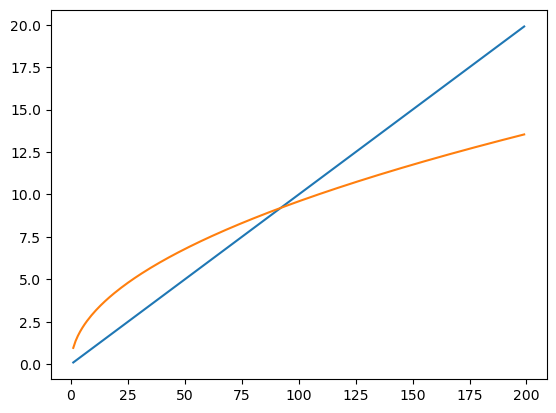

In [5]:
epsilon = .1
delta_p = 1e-5

def query():
    return len(adult_data[adult_data['Martial Status'] == 'Divorced'])

def avg_attack(k):
    return np.mean([laplace_mech(query(), 1, epsilon) for i in range(k)])
    
xs = range(1, 200)
privacy_cost_sequential = [k * epsilon for k in xs]
privacy_cost_advanced = [2 * epsilon * np.sqrt(2 * k * np.log(1/delta_p)) for k in xs]

plt.plot(xs, privacy_cost_sequential);
plt.plot(xs, privacy_cost_advanced);

In 2-5 sentences, answer the following:
- At approximately what point do the lines representing the two approaches cross? What does this mean about **which** composition technique should be used for an iterative algorithm?
- The two lines represent **different** privacy costs for the **same** algorithm. How can both be correct?

The lines cross at around 90 meaning that on k lower than that sequential composition is better ad on k higher - advanced

Same correct but sequential is the upperbound while advanced is more accurate




## Question 4 (10 points)

Consider the code below, which defines three average queries and runs them on `adult_data`, using the Laplace mechanism to provide differential privacy with $\epsilon = 1$ for each query.

In [6]:
b_capgain = 10000
b_age = 3000

epsilon = 1

def query1():
    return np.sum(adult['Capital Gain'].clip(lower=0, upper=b_capgain))

def query2():
    return len(adult[adult['Education-Num'] < 10])

def query3():
    return np.sum(adult['Age'].clip(lower=0, upper=b_age))

def my_query():
    return [query1(), query2(), query3()]

my_query()

[np.int64(17145231), 14754, np.int64(1256257)]

In 2-5 sentences, answer the following:
- What is the $L_1$ global sensitivity of `my_query`, and why?
- What is the $L_2$ global sensitivity of `my_query`, and why?

1) L1 = 10000 + 1 + 3000 = 13001; Since queries 1 2 adnd 3 chnge the result respectively
2) L2 = sqrt(10000^2 + 1^2 + 3000^2) = 10440 (approx); Using L2 formula with same query cost

## Question 5 (5 points)

In the cell below, write code to release the results of calling `my_query()` with differential privacy, without using sequential composition.

*Hint*: use `laplace_mech_vec`, but be careful of sensitivity!

In [7]:
def my_query_lap(epsilon):
    return laplace_mech_vec(my_query(), 13001, epsilon)

my_query_lap(1.0)

[np.float64(17092197.201529082),
 25738.6393221586,
 np.float64(1230433.6301959297)]

### Question 6 (5 points)

In the cell below, write code to release the results of `my_query()` with differential privacy, but using the Gaussian mechanism.

*Hint*: remember to use $L_2$ sensitivity

In [8]:
def my_query_gauss(epsilon, delta):
    return gaussian_mech_vec(my_query(), np.sqrt(10000**2 + 1**2 + 3000**2), epsilon, delta)

my_query_gauss(1.0, 1e-5)

[np.float64(17104668.746106464),
 117491.45041076187,
 np.float64(1246716.2758200124)]